## COMPLETE EDA + PREPROCESSING NOTEBOOK

1. IMPORTS

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler

sns.set_style("darkgrid")

2. LOAD DATA

In [13]:
df = sns.load_dataset('titanic')

3. DATA OVERVIEW

In [14]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
df.shape

(891, 15)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [17]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observations:
- Dataset contains ~891 rows and multiple features including numerical and categorical variables
- Target variable is survived
- Features like age, deck, and embarked contain missing values
- Numerical features like fare show high variance

Insights:
- Dataset contains mixed data types requiring preprocessing
- Missing values must be handled before modeling
- fare may contain extreme values (possible outliers)

Separate numerical & categorical columns

In [18]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category','bool']).columns

4. DATA CLEANING

In [19]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Observations:
- deck has a very high number of missing values
- age has moderate missing values
- embarked has very few missing values


Insights:
- deck is not reliable → should be dropped
- age should be imputed (median preferred due to skew)
- embarked can be filled with mode

Handling:

In [20]:
# Numerical
df['age'].fillna(df['age'].median(), inplace=True)

# Categorical
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Drop high-missing column
df.drop(columns=['deck'], inplace=True)

Duplicates:

In [21]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

Data Types:

In [23]:
df.dtypes
# Seems Normal

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

Observation:
- No missing values remain


Insight:
- Dataset is now clean and ready for analysis

5. UNIVARIATE ANALYSIS

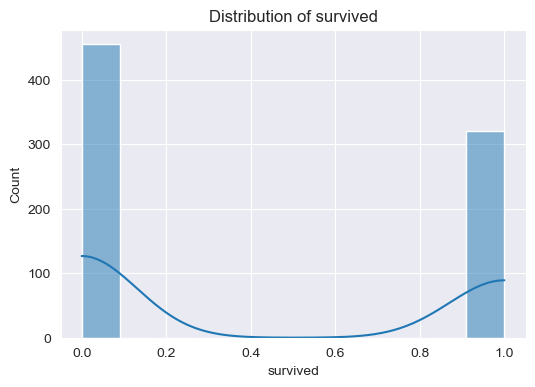

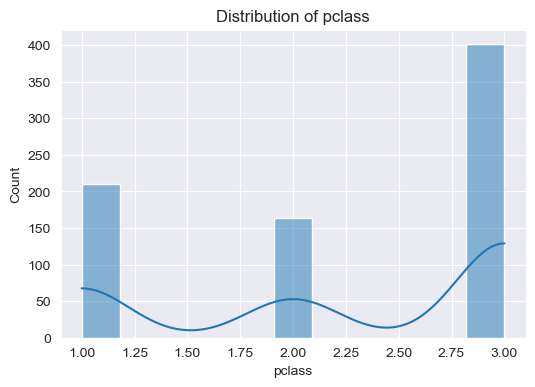

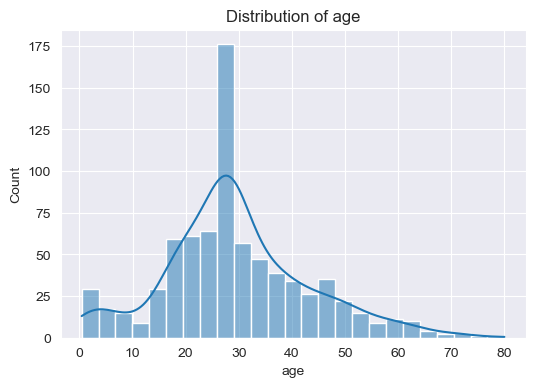

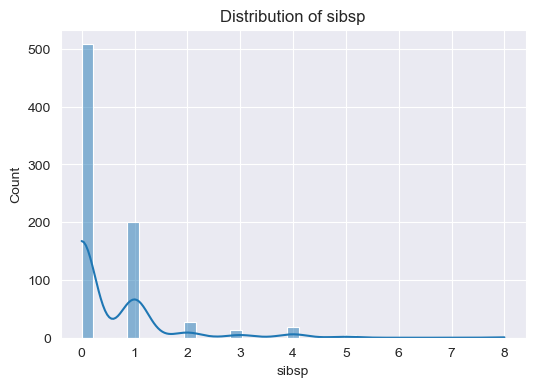

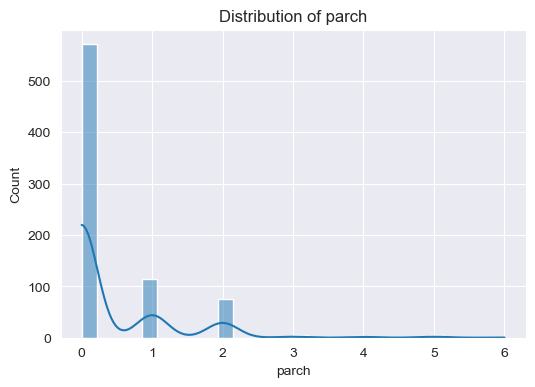

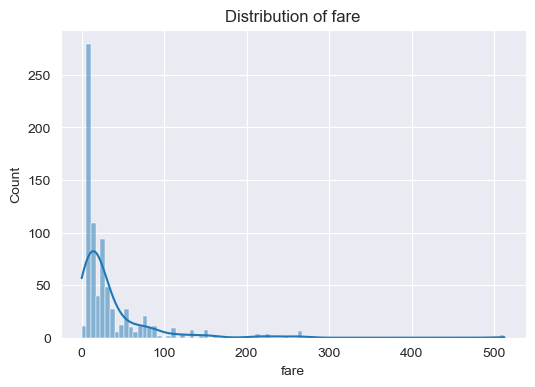

In [27]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Observations:
- Age distribution is approximately normal with slight right skew
- Majority of passengers are between 20–40 years
- Fare distribution is highly right-skewed
- Few passengers paid significantly higher fares


Insights:
- Titanic passengers were mostly young adults
- Slight skew indicates presence of older passengers
- Most passengers traveled in lower fare classes
- High fares likely represent premium class passengers

In [34]:
cat_cols = cat_cols.drop('deck')

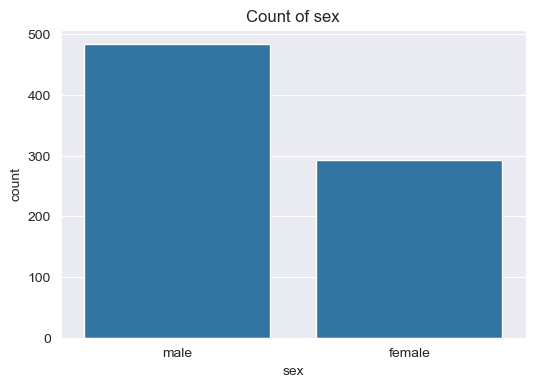

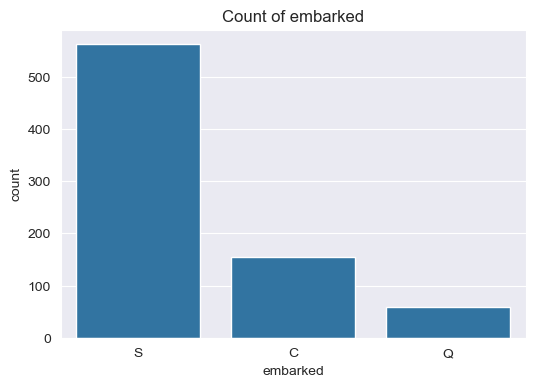

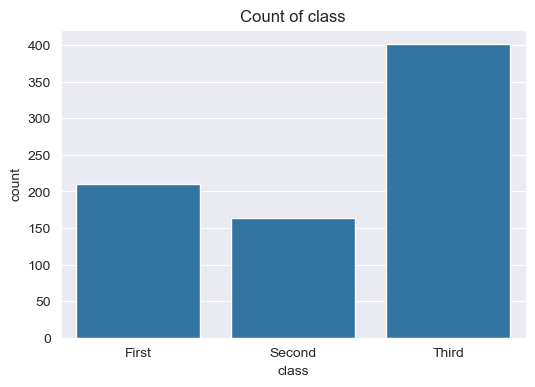

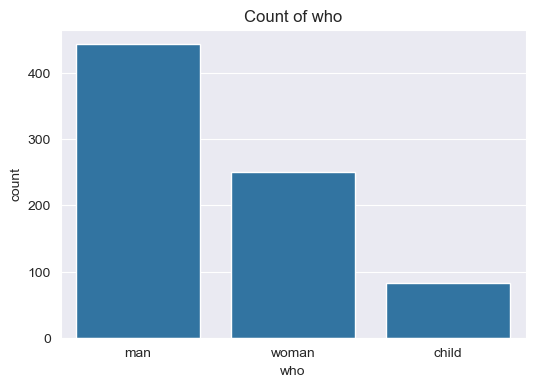

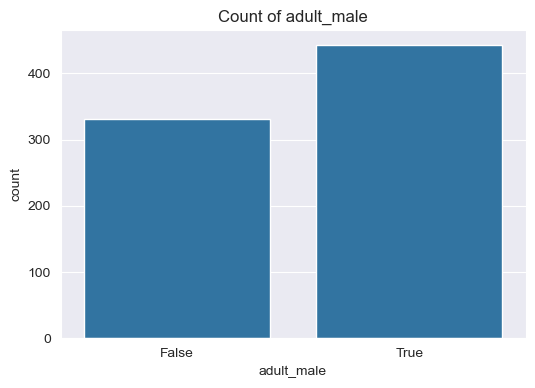

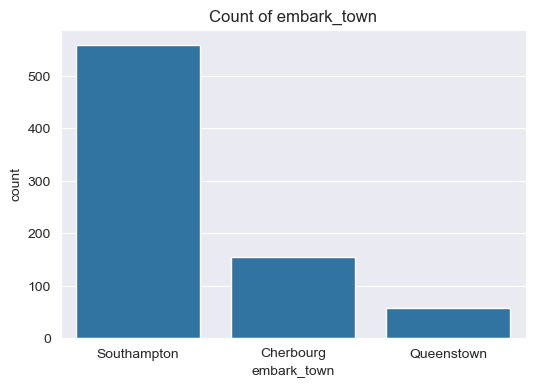

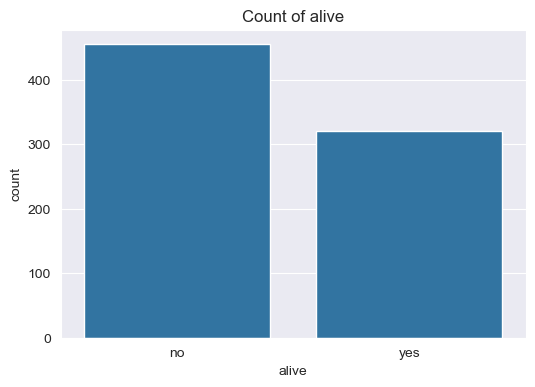

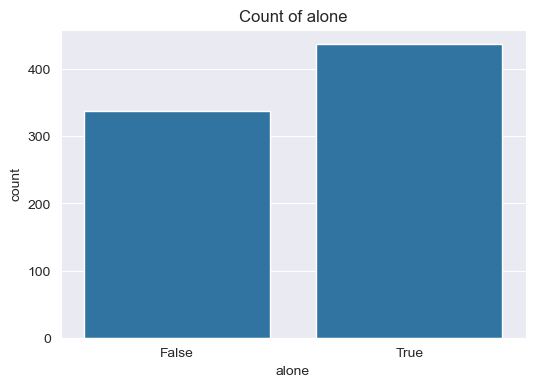

In [35]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,data=df)
    plt.title(f"Count of {col}")
    #plt.xticks(rotation=45)
    plt.show()

6. BIVARIATE ANALYSIS

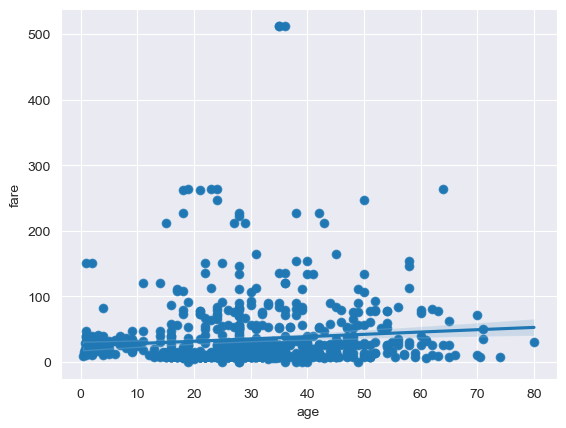

In [38]:
sns.scatterplot(x='age',y='fare',data=df)
sns.regplot(x='age',y='fare',data=df)
plt.show()

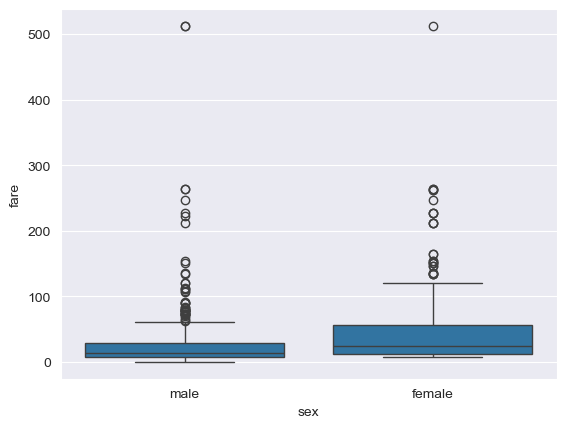

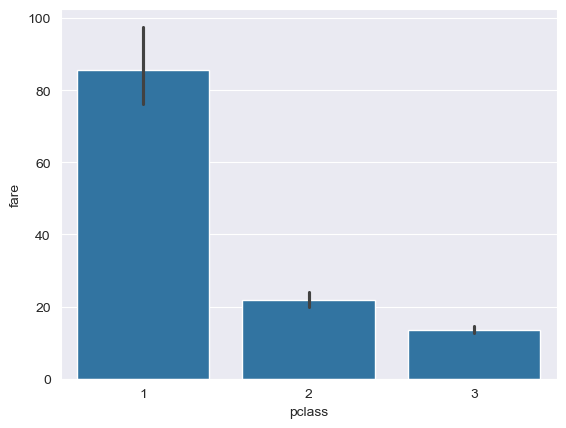

In [39]:
sns.boxplot(x='sex', y='fare', data=df)
plt.show()

sns.barplot(x='pclass', y='fare', data=df)
plt.show()

In [42]:
pd.crosstab(df['sex'], df['survived'])

survived,0,1
sex,,
female,76,216
male,379,104


Observations:
- Female survival rate is significantly higher than male
- First-class passengers have highest survival rate
- Third-class passengers have lowest survival rate
- No strong relationship between age and fare
- Fare values are spread across all age groups

Insights:
- Gender played a critical role in survival
- Likely due to “women and children first” evacuation policy
- Socioeconomic status strongly influenced survival
- Higher-class passengers likely had better access to lifeboats
- Ticket price is independent of age
- Fare is likely determined by passenger class

7. MULTIVARIATE ANALYSIS

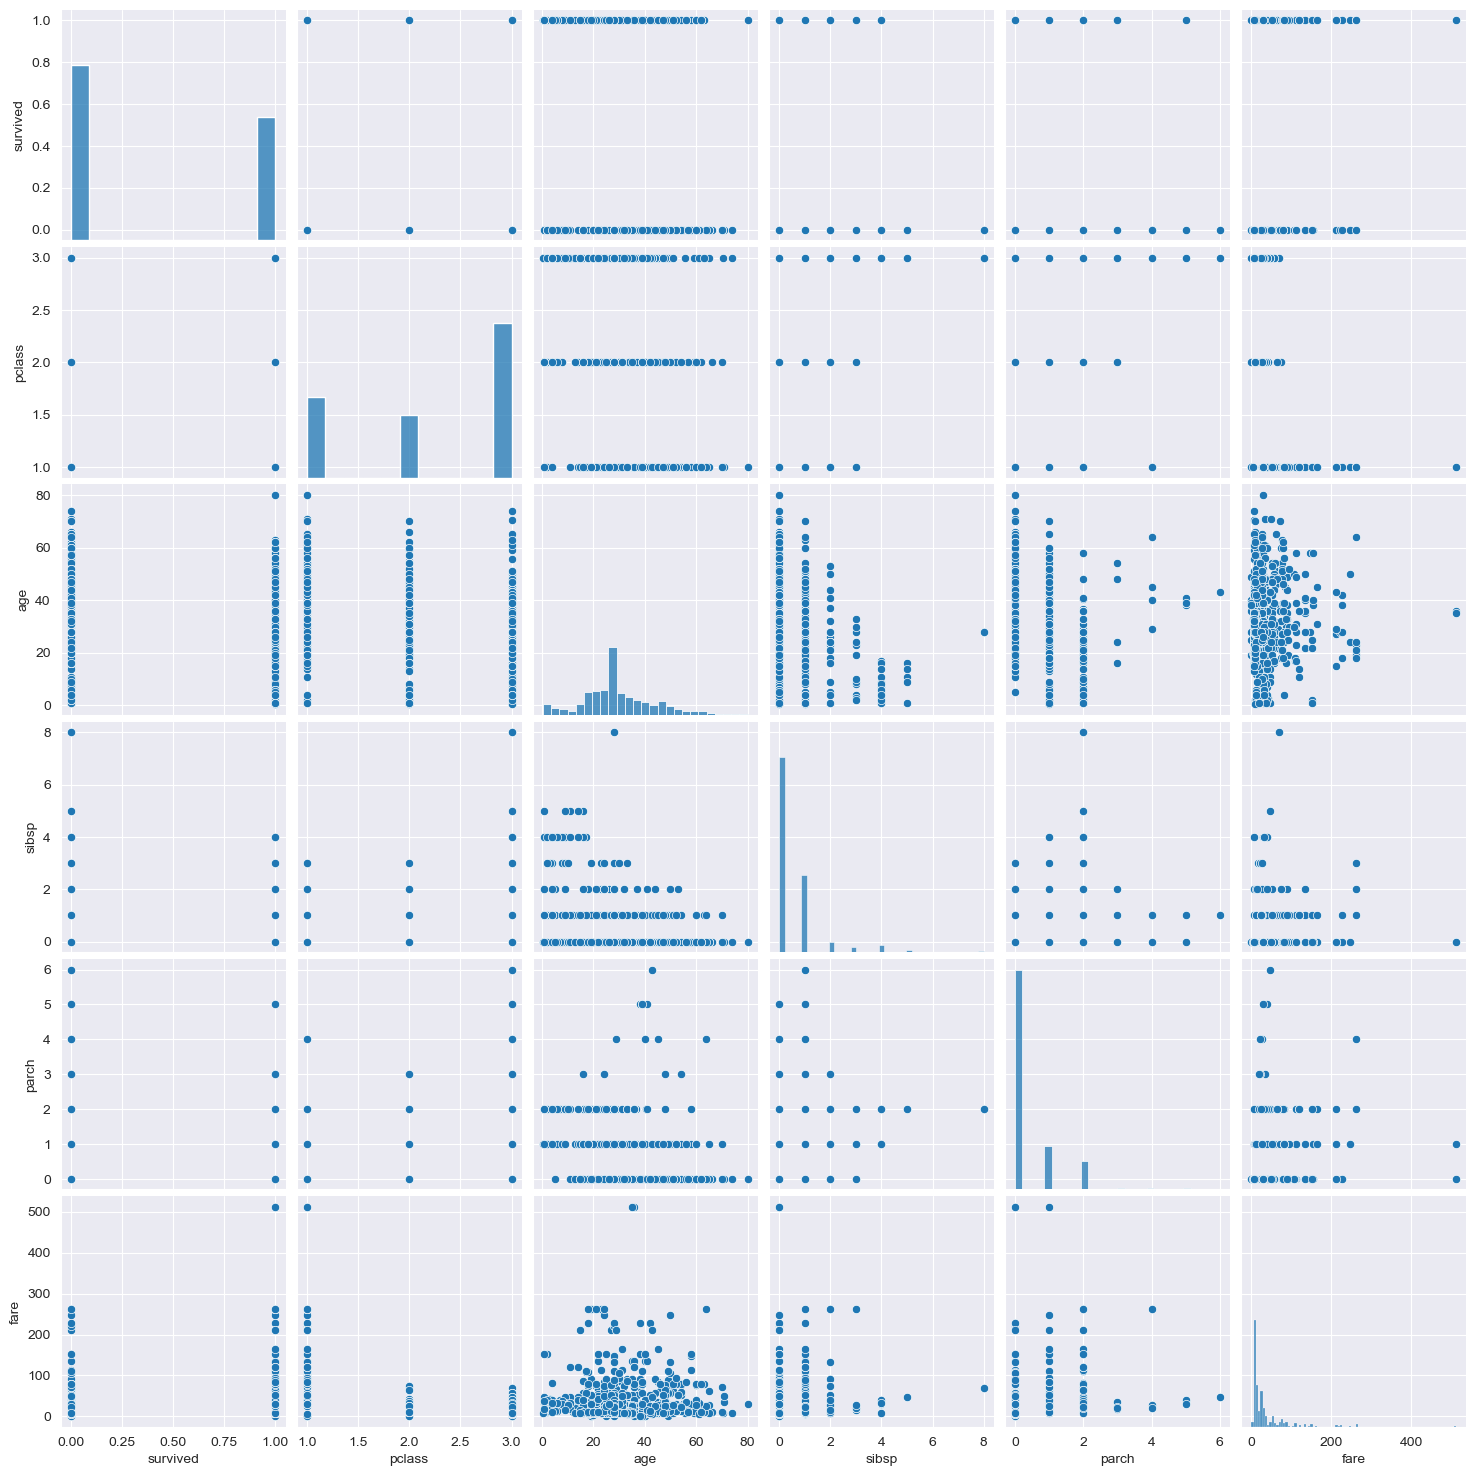

In [43]:
sns.pairplot(df[num_cols])
plt.show()

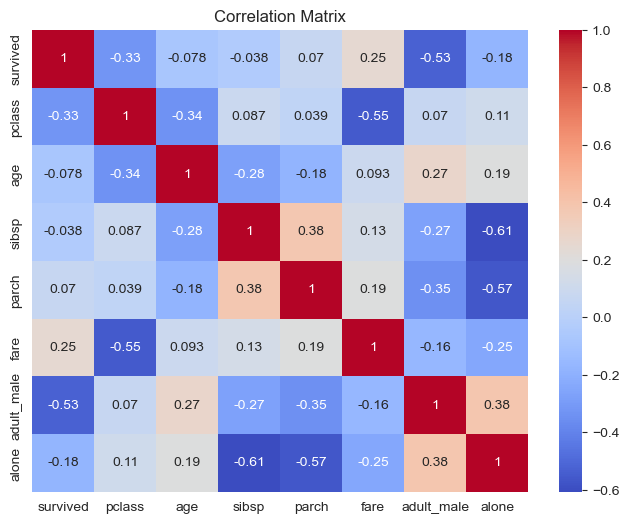

In [44]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Observations:
- fare positively correlates with survival
- pclass negatively correlates with survival
- age has weak correlation with survival


Insights:
- Higher fare (better class) increases survival probability
- Passenger class is a strong predictor of survival
- Age alone is not a strong predictor

8. OUTLIER DETECTION

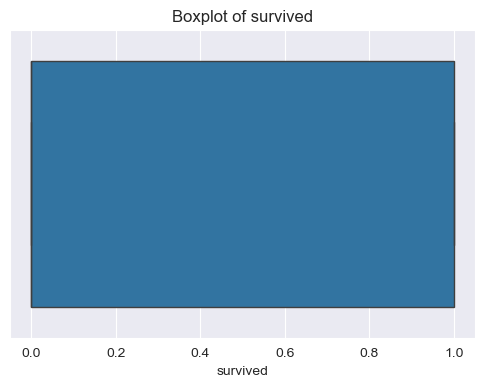

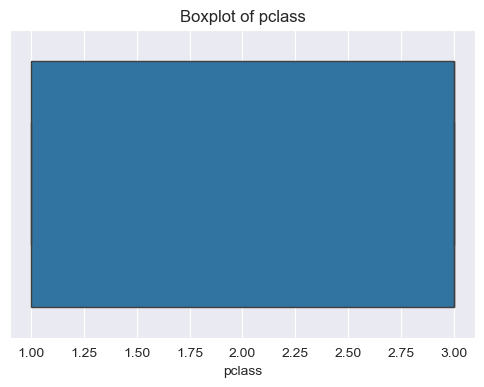

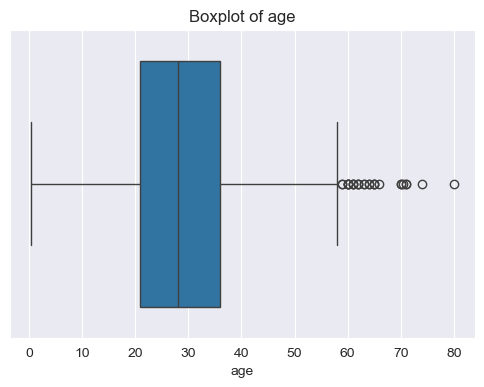

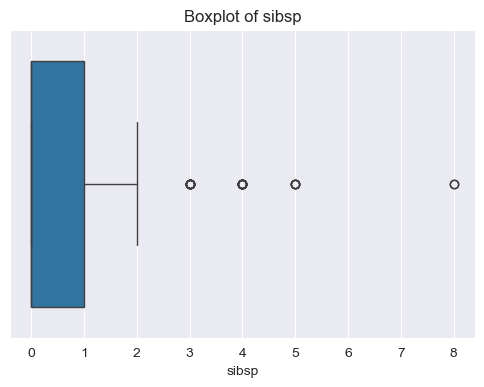

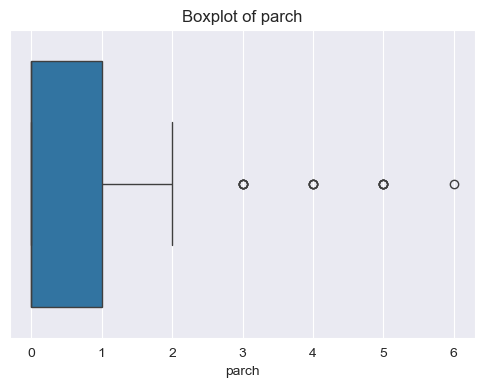

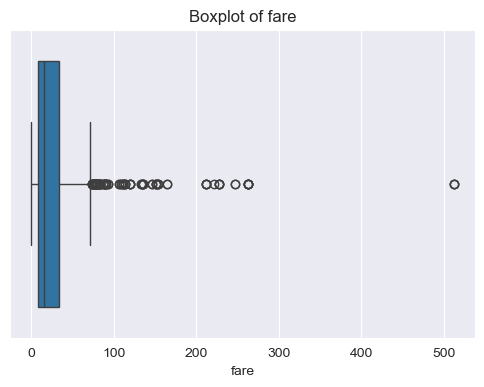

In [46]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Observations:
- Significant number of high-value outliers


Insights:
- Outliers represent real premium passengers
- Should not be removed → transformation preferred

In [48]:
# IQR Method
def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] < lower) | (df[col] > upper)]

outliers_fare = detect_outliers('fare')
len(outliers_fare)

102

Handling (Transform)

In [49]:
df['log_fare'] = np.log(df['fare'] + 1)

9. SUMMARY STATISTICS

In [50]:
df[num_cols].mean()
df[num_cols].median()
df[num_cols].std()
df[num_cols].skew()
df[num_cols].kurt()

survived    -1.879198
pclass      -1.449724
age          0.567323
sibsp       12.608666
parch        8.837563
fare        29.905898
dtype: float64

10. FEATURE ENGINEERING

Create new features

In [51]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

Encode categorical

In [54]:
df_encoded = pd.get_dummies(df, drop_first=True)

11. FEATURE SELECTION

Correlation-based removal

In [55]:
corr_matrix = df_encoded.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df_encoded.drop(columns=to_drop, inplace=True)

12. SCALING

In [56]:
scaler = StandardScaler()

num_cols = df_encoded.select_dtypes(include=['int64','float64']).columns

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

13. FINAL INSIGHTS

- Most passengers are young adults (20–40)
- Females have significantly higher survival rate
- Fare is strongly linked to passenger class
- High fare values represent real premium passengers, not errors
- Total_bill-like relationships (fare vs class) influence survival